In [1]:
import sys
import os
import subprocess

print("🔄 Initialisation de l'environnement...")

# --- 1. GESTION DES LIBRAIRIES EXTERNES (Téléchargement auto) ---
def install_package(package):
    print(f"   ⏳ Téléchargement de '{package}' en cours...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    # On essaie d'importer les librairies "publiques"
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("✅ Toutes les librairies externes sont déjà présentes.")

except ImportError as e:
    # Si une librairie manque (ex: seaborn), on installe tout le paquet d'un coup
    print(f"⚠️ Il manque des librairies (Erreur: {e}). Installation en cours...")
    
    # On installe les classiques qui manquent souvent sur SSP Cloud
    pkgs = ["pandas", "matplotlib", "seaborn", "tqdm", "torch", "torchvision"]
    for pkg in pkgs:
        try:
            __import__(pkg) # Tente un import basique
        except ImportError:
            install_package(pkg)
            
    # On refait les imports après installation
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("✅ Installation terminée et librairies chargées.")


# --- 2. GESTION DE TES FICHIERS LOCAUX (Neural_networks.py, etc) ---
try:
    # C'est ici qu'on charge ton code à toi
    from Neural_networks import *
    from Comparing_results import *
    print("✅ Tes fichiers locaux (Neural_networks, Comparing_results) sont bien chargés.")

except ImportError as e:
    print("\n" + "="*60)
    print(f"❌ ERREUR : Impossible de trouver le fichier '{e.name}'.")
    print("👉 SOLUTION : Tu dois 'Uploader' (Glisser-Déposer) tes fichiers .py")
    print("   (Neural_networks.py, Comparing_results.py, Helper_functions.py)")
    print("   dans la barre de gauche de VS Code ou Jupyter.")
    print("="*60 + "\n")


# --- 3. VÉRIFICATION GPU (Pour être sûr que tu vas vite) ---
if torch.cuda.is_available():
    print(f"\n🚀 EXCELLENT : GPU détecté -> {torch.cuda.get_device_name(0)}")
else:
    print("\n⚠️ ATTENTION : Aucun GPU détecté. L'entraînement sera lent (CPU).")

🔄 Initialisation de l'environnement...
✅ Toutes les librairies externes sont déjà présentes.
Helper functions loaded. User device: cuda
Neural Networks loaded. User device: cuda
✅ Tes fichiers locaux (Neural_networks, Comparing_results) sont bien chargés.

🚀 EXCELLENT : GPU détecté -> NVIDIA A2


In the Lottery Ticket Hypothesis paper, the authors propose two different iterative pruning strategies to find the winning tickets. 

Strategy 1: Iterative pruning with resetting.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations, reaching parameters m⊙θ_j.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Reset the weights of the remaining portion of the network to their values in θ0. That is, let
θ= θ_0.
5. Let m = m' and repeat steps 2 through 4 until a sufficiently pruned network has been
obtained.


Strategy 2: Iterative pruning with continued training.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Let m= m' and repeat steps 2 and 3 until a sufficiently pruned network has been obtained.
5. Reset the weights of the remaining portion of the network to their values in θ_0. That is, let
θ= θ_0.

The difference between the two strategies is the reinitialization of the weights after pruning. 
At step 3, s% of the parameters are pruned, and we create a mask. In strategy 1, the unmasked 
weights are being reset to their value from θ_0 and then the pruning steps are being repeated.
In strategy 2, after pruning, the weights are kept at their post-trained values to then be 
trained again with only the unpruned weights. It is at the end when the model has been sufficiently 
pruned that we train it one final time with θ_0 .

According to the paper, the first strategy offers better results. In this section, we propose to 
check this claim.

In [2]:
# Détection automatique du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Method 1 : Ticket Gagnant (Poids d'origine).

Method 2 : Ticket Aléatoire (Poids détruits et remplacés par du hasard, car LTH=False).

But : Prouver que les poids de départ sont spéciaux.

 Lancement de la comparaison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/2 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 96.33%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
   [Pruning Debug] Target Global Percent: 77.64%
      Layer fc1.weight | Threshold: 0.03946 | Zeros: 182607/235200 (77.6%)
      Layer fc2.weight | Threshold: 0.05894 | Zeros: 23291/30000 (77.6%)
   -> Output Layer detected (fc3.weight): Pruning half (38.82%)
      Layer fc3.weight | Threshold: 0.05064 | Zeros: 388/1000 (38.8%)
Current pruning percentage: 77.49%
Accuracy after retraining: 96.59%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
   [Pruning Debug] Target Global Percent: 95.00%
      Layer fc1.weight | Threshold: 0.07083 | Zeros: 223440/235200 (95.0%)
      Layer fc2.weight | Threshold: 0.08947 | Zeros: 28500/30000 (95.0%)
   -> Output Layer detected (fc3.weight): Pruning half (47.50%)
     

Repeats:  50%|█████     | 1/2 [01:33<01:33, 93.47s/it]

Accuracy after retraining: 96.15%

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 96.47%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 77.64% of the remaining weights.

--- Round 1/2 ---
Current pruning percentage (Method 1): 77.64%
   [Pruning Debug] Target Global Percent: 77.64%
      Layer fc1.weight | Threshold: 0.03982 | Zeros: 182607/235200 (77.6%)
      Layer fc2.weight | Threshold: 0.05982 | Zeros: 23291/30000 (77.6%)
   -> Output Layer detected (fc3.weight): Pruning half (38.82%)
      Layer fc3.weight | Threshold: 0.04675 | Zeros: 388/1000 (38.8%)
Current pruning percentage: 77.49%
Accuracy after retraining: 96.71%

--- Round 2/2 ---
Current pruning percentage (Method 1): 95.00%
   [Pruning Debug] Target Global Percent: 95.00%
      Layer fc1.weight | Threshold: 0.07090 | Zeros: 223440/235200 (95.0%)
      Layer fc2.weight | Threshold: 0.09142 | Zeros: 28500/30000 (95.0%)
   -> Output Layer detected (fc3.we

Repeats: 100%|██████████| 2/2 [03:15<00:00, 97.72s/it]

Accuracy after retraining: 96.07%
Total time: 3.26 minutes


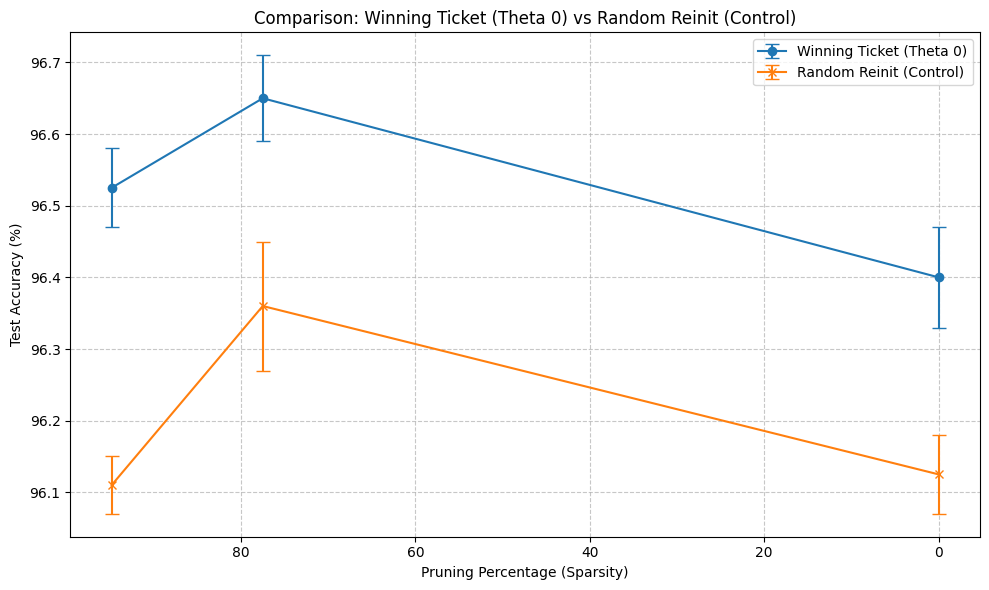

In [3]:
############## REPRODUCTION EXPÉRIENCE PRINCIPALE (Figure 1 du papier) - TEST PIPELINE ########################

# Paramètres du papier pour MNIST (LeNet-300-100)
total_prune_percent = 95  # On va jusqu'à 95% ou 98% pour bien voir la différence
rounds = 2               # Plus de rounds pour une courbe plus lisse (IMP)
epochs_per_round = 1     # Suffisant pour voir la convergence
amount_of_repeats = 2     # 3 à 5 répétitions pour avoir des barres d'erreur fiables

# --- MÉTHODE 1 : Le Ticket Gagnant (Winning Ticket) ---
# On réinitialise les poids à Theta_0 à chaque tour.
def method_1_Winning_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # Active le mécanisme "Lottery Ticket"
        strategy_1=True   # Force le reset à Theta_0 à chaque tour (IMP standard)
    )

# --- MÉTHODE 2 : Réinitialisation Aléatoire (Control Experiment) ---
# On garde le masque (la structure), mais on met des poids aléatoires.
# C'est ça qui prouve que l'initialisation est la clé !
def method_2_Random_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False         # False désactive Theta_0 -> Lance "randomly_reinitialize"
    )

print(" Lancement de la comparaison : Winning Ticket vs Random Ticket...")

# Lancement de l'expérience comparative
df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

# Affichage du graphique
comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)"
)

🚀 Lancement de la comparaison : Winning Ticket vs Random Ticket...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


🚀 Starting MNIST Experiment on cuda...
Step 1: Initial training...
Initial accuracy: 97.95%

--- Round 1/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.97%

--- Round 2/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.76%

--- Round 3/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 98.03%

--- Round 4/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 98.06%

--- Round 5/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.82%

--- Round 6/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97

Repeats:  33%|███▎      | 1/3 [53:49<1:47:39, 3230.00s/it]

Accuracy: 97.84%

🚀 Starting MNIST Experiment on cuda...
Step 1: Initial training...
Initial accuracy: 97.70%

--- Round 1/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.76%

--- Round 2/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 98.12%

--- Round 3/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.95%

--- Round 4/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.95%

--- Round 5/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 98.06%

--- Round 6/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pr

Repeats:  67%|██████▋   | 2/3 [1:47:33<53:45, 3225.89s/it]

Accuracy: 98.02%

🚀 Starting MNIST Experiment on cuda...
Step 1: Initial training...
Initial accuracy: 97.82%

--- Round 1/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.77%

--- Round 2/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.71%

--- Round 3/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 98.00%

--- Round 4/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.85%

--- Round 5/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pruned
Accuracy: 97.51%

--- Round 6/15 ---
Output layer detected (fc3.weight): Pruning at 9.051813626104233% (vs 18.103627252208465%)
Sparsity: 18.07% pr

Repeats: 100%|██████████| 3/3 [2:43:57<00:00, 3279.02s/it]

Accuracy: 98.00%
Total time: 163.95 minutes


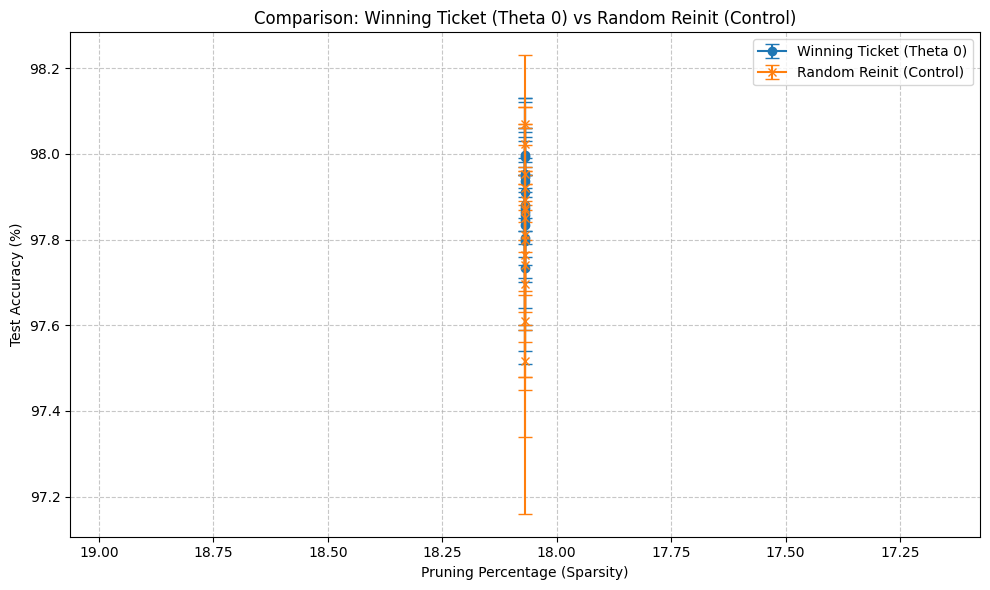

In [3]:
############## REPRODUCTION EXPÉRIENCE PRINCIPALE (Figure 1 du papier) ########################

# Paramètres du papier pour MNIST (LeNet-300-100)
total_prune_percent = 95  # On va jusqu'à 95% ou 98% pour bien voir la différence
rounds = 15               # Plus de rounds pour une courbe plus lisse (IMP)
epochs_per_round = 10     # Suffisant pour voir la convergence
amount_of_repeats = 3     # 3 à 5 répétitions pour avoir des barres d'erreur fiables

# --- MÉTHODE 1 : Le Ticket Gagnant (Winning Ticket) ---
# On réinitialise les poids à Theta_0 à chaque tour.
def method_1_Winning_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # Active le mécanisme "Lottery Ticket"
        strategy_1=True   # Force le reset à Theta_0 à chaque tour (IMP standard)
    )

# --- MÉTHODE 2 : Réinitialisation Aléatoire (Control Experiment) ---
# On garde le masque (la structure), mais on met des poids aléatoires.
# C'est ça qui prouve que l'initialisation est la clé !
def method_2_Random_Ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=False         # False désactive Theta_0 -> Lance "randomly_reinitialize"
    )

print(" Lancement de la comparaison : Winning Ticket vs Random Ticket...")

# Lancement de l'expérience comparative
df_avg_acc_winning, df_avg_acc_random = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Winning_Ticket, 
    method_2=method_2_Random_Ticket
)

# Affichage du graphique
comparing_methods_plotting(
    df_avg_acc_winning, 
    df_avg_acc_random, 
    "Winning Ticket (Theta 0)", 
    "Random Reinit (Control)"
)

Method 1 : On remet les poids à zéro à chaque round.

Method 2 : On ne remet pas à zéro, on continue d'entraîner (Fine-tuning) et on ne remet à zéro qu'à la toute fin.

But : Voir quelle méthode d'entraînement est la plus efficace pour trouver le ticket.

In [ ]:
############## COMPARAISON : STRATEGY 1 (Reset) vs STRATEGY 2 (Fine-Tuning) ########################

total_prune_percent = 95
rounds = 15
epochs_per_round = 10
amount_of_repeats = 3

# --- STRATEGY 1 : Reset à chaque tour (Standard LTH) ---
def method_1_Strategy1():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # On veut le ticket gagnant
        strategy_1=True   # OUI : On reset à Theta_0 à chaque itération
    )

# --- STRATEGY 2 : Fine-tuning (Reset seulement à la fin) ---
def method_2_Strategy2():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent, 
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,         # On veut le ticket gagnant
        strategy_1=False  # NON : On garde les poids entraînés (Theta_j) entre les tours
    )

print(" Lancement de la comparaison : Strategy 1 (Reset) vs Strategy 2 (Continu)...")

df_strat1, df_strat2 = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats, 
    rounds=rounds, 
    method_1=method_1_Strategy1, 
    method_2=method_2_Strategy2
)

comparing_methods_plotting(
    df_strat1, 
    df_strat2, 
    "Strategy 1 (Reset)", 
    "Strategy 2 (Fine-tuning)"
)

Comparaison : Iterative Pruning (IMP) vs One-Shot Pruning
Hypothèse : L'approche progressive maintient la précision plus longtemps que l'approche brutale.

Le test : Compare l'élagage progressif (enlever 20% par tour pendant 15 tours) contre l'élagage brutal (enlever 95% d'un coup).

Le but : Montrer que l'approche itérative (IMP) trouve de meilleurs tickets gagnants que l'approche directe, surtout pour des taux de compression élevés.

In [ ]:
############## COMPARAISON 1 : ITERATIVE vs ONE-SHOT ########################

# Paramètres
total_prune_percent = 95  # Cible très agressive (95% de vide)
rounds = 15               # Nombre d'étapes pour l'itératif
epochs_per_round = 10     
amount_of_repeats = 3     

# Méthode 1 : Iterative Magnitude Pruning (IMP)
# On enlève un petit peu à chaque tour (Progressif)
def method_imp():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent,
        rounds=rounds,
        epochs_per_round=epochs_per_round,
        LTH=True, 
        one_shot=False # <--- IMP
    )

# Méthode 2 : One-Shot Pruning
# On enlève tout d'un coup (Brutal)
def method_oneshot():
    return iterative_pruning_MNIST(
        total_prune_percent=total_prune_percent,
        rounds=rounds, 
        epochs_per_round=epochs_per_round,
        LTH=True,
        one_shot=True  # <--- ONE SHOT (Ignore les rounds, saute à la fin)
    )

print("🚀 Lancement : Iterative vs One-Shot...")

df_imp, df_oneshot = comparing_methods_initialization_after_pruning(
    amount_of_repeats=amount_of_repeats,
    rounds=rounds,
    method_1=method_imp,
    method_2=method_oneshot
)

# Le graphique montrera la courbe d'apprentissage progressive (IMP)
# comparée au "saut" brutal du One-Shot (souvent moins bon)
comparing_methods_plotting(df_imp, df_oneshot, "Iterative Pruning (IMP)", "One-Shot Pruning")

Comparaison : Dense vs Sparse (Winning Ticket)
Hypothèse : Le Winning Ticket (à 95% vide) est aussi performant que le réseau Dense (100% plein).

Le test : Compare les performances du réseau complet initial (100% des poids) contre le Winning Ticket (ex: 5% des poids restants).

Le but : Montrer qu'un réseau avec 95% de poids en moins peut atteindre la même précision (voire meilleure) que le réseau géant d'origine.

In [ ]:
############## COMPARAISON 2 : DENSE (Baseline) vs SPARSE (Winning Ticket) ########################

# Paramètres
target_sparsity = 95      # On veut comparer le Dense à un réseau vide à 95%
rounds = 15
epochs = 10
repeats = 3

# Méthode 1 : Réseau Dense (Control)
# On définit 0% de pruning. C'est le réseau complet normal.
def method_dense_baseline():
    return iterative_pruning_MNIST(
        total_prune_percent=0, # <--- 0% de pruning = Dense
        rounds=1,              # 1 seul tour suffit pour avoir la baseline
        epochs_per_round=epochs,
        LTH=True
    )

# Méthode 2 : Winning Ticket (Sparse)
# Le réseau élagué via IMP
def method_sparse_ticket():
    return iterative_pruning_MNIST(
        total_prune_percent=target_sparsity,
        rounds=rounds,
        epochs_per_round=epochs,
        LTH=True
    )

print("🚀 Lancement : Dense Baseline vs Sparse Winning Ticket...")

df_dense, df_sparse = comparing_methods_initialization_after_pruning(
    amount_of_repeats=repeats,
    rounds=rounds, # Note: le dense s'arrêtera avant, mais le code gère ça
    method_1=method_dense_baseline,
    method_2=method_sparse_ticket
)

# Sur le graphique :
# - "Dense" sera un point (ou une courte ligne) tout à gauche (0% sparsity).
# - "Sparse" sera une courbe qui va vers la droite.
# REGARDEZ LA FIN DE LA COURBE : Si elle est à la même hauteur que le point Dense, l'hypothèse est validée !
comparing_methods_plotting(df_dense, df_sparse, "Dense Network (100% weights)", f"Winning Ticket ({target_sparsity}% pruned)")

  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.0%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 93.34%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 91.39%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 91.56%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Acc

 20%|██        | 1/5 [09:08<36:35, 548.92s/it]

Accuracy after retraining: 95.72%

Iteration for average : 2/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.6%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.99%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 95.05%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 94.25%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Curr

 40%|████      | 2/5 [18:16<27:24, 548.20s/it]

...

Accuracy after retraining: 96.07%

Iteration for average : 4/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 91.8%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 95.38%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 95.00%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 95.20%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Curr

 80%|████████  | 4/5 [37:27<09:27, 567.23s/it]

Accuracy after retraining: 96.84%

Iteration for average : 5/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.19%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.08%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 94.22%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 93.86%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Cur

100%|██████████| 5/5 [46:58<00:00, 563.63s/it]

Accuracy after retraining: 95.18%
46.97020970582962


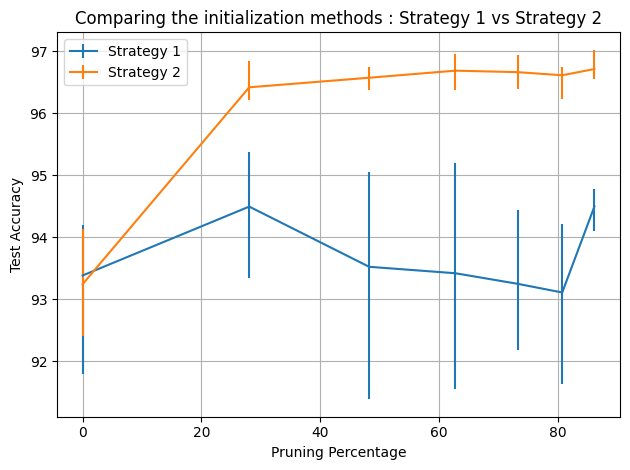

In [2]:
############## Comparing the two strategies in the appendix ##########################################################

total_prune_percent = 90
rounds = 7
amount_of_repeats = 5

def method_1_LTH_strategy1():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=True)
def method_2_LTH_strategy2():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, strategy_1=False)

df_avg_acc_method_1, df_avg_acc_method_2 = comparing_methods_initialization_after_pruning(amount_of_repeats = amount_of_repeats, rounds = rounds, method_1=method_1_LTH_strategy1, method_2=method_2_LTH_strategy2)
comparing_methods_plotting(df_avg_acc_method_1, df_avg_acc_method_2, "Strategy 1", "Strategy 2")

On page 2 of the Lottery Ticket Hypothesis paper, the authors claim that the strength of their unique pruning technique
comes from the fact that after pruning, the weights are set back to their original weights (from the dense model). From
there, the model is retrained and the test accuracies are as good, if not better then they were originally.

We want to test this theory by randomly reinitializing the not-pruned weights, and seeing the test accuracies.

  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.86%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.09%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 94.93%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 93.40%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Ac

 20%|██        | 1/5 [09:30<38:00, 570.10s/it]

Accuracy after retraining: 96.42%

Iteration for average : 2/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.38%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.51%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 93.07%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 92.49%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Cur

 40%|████      | 2/5 [18:57<28:25, 568.61s/it]

...

Accuracy after retraining: 96.42%

Iteration for average : 4/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.34%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.96%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 93.98%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 93.22%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Cur

 80%|████████  | 4/5 [37:58<09:29, 569.68s/it]

Accuracy after retraining: 95.93%

Iteration for average : 5/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.42%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.28% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 28.03%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 28.03%
Accuracy after retraining: 94.26%

--- Round 2/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 95.24%

--- Round 3/7 ---
Current pruning percentage (Method 1): 62.72%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 62.72%
Accuracy after retraining: 93.95%

--- Round 4/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Cur

100%|██████████| 5/5 [47:22<00:00, 568.50s/it]

Accuracy after retraining: 96.41%
47.375510132312776


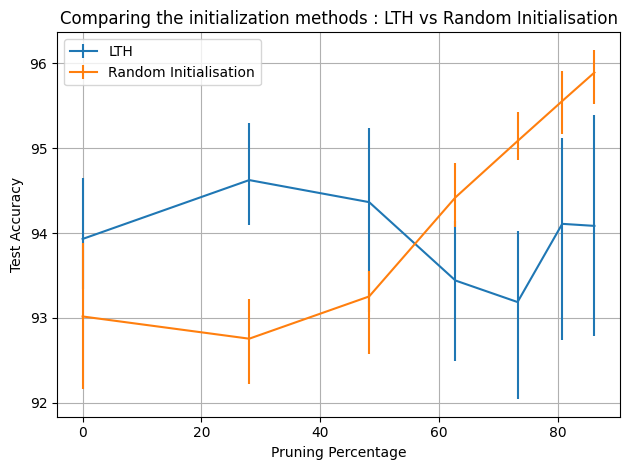

In [3]:
############## Comparing initialization after pruning ##########################################################
total_prune_percent = 90
rounds = 7
amount_of_repeats = 5

def method_1_LTH():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=True)
def method_2_random():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=False)

df_avg_acc_method_1, df_avg_acc_method_2 = comparing_methods_initialization_after_pruning(amount_of_repeats = amount_of_repeats, rounds = rounds, method_1=method_1_LTH, method_2=method_2_random)
comparing_methods_plotting(df_avg_acc_method_1, df_avg_acc_method_2, "LTH", "Random Initialisation")

### Test pour les données CIFAR 

In [3]:
# Configuration "Micro-Expérience" pour CPU
# On fait le minimum vital pour voir si le code plante ou tourne
cifar_test_repeats = 1      # Une seule répétition pour tester
cifar_test_rounds = 1       # Un seul round d'élagage
cifar_test_epochs = 2       # 2 epochs seulement (assez pour voir la loss bouger, pas pour converger)
cifar_prune_rate = 20       # On élague 20% juste pour tester le mécanisme


In [4]:
# Wrapper 1 : Winning Ticket sur CIFAR
def method_cifar_lth():
    # Note : iterative_pruning_CIFAR utilise votre classe SimpleCNN par défaut
    return iterative_pruning_CIFAR(
        total_prune_percent=cifar_prune_rate,
        rounds=cifar_test_rounds,
        epochs_per_round=cifar_test_epochs,
        lr=0.001,
        LTH=True
    )

In [5]:
# Wrapper 2 : Random Initialization sur CIFAR (Control)
def method_cifar_random():
    return iterative_pruning_CIFAR(
        total_prune_percent=cifar_prune_rate,
        rounds=cifar_test_rounds,
        epochs_per_round=cifar_test_epochs,
        lr=0.001,
        LTH=False
    )

In [6]:
# Lancement de la comparaison (Réutilisation de votre fonction générique)
# Cela va entraîner le modèle LTH, puis le modèle Random, et comparer les deux.
df_cifar_lth, df_cifar_rand = comparing_methods_initialization_after_pruning(
    amount_of_repeats=cifar_test_repeats, 
    rounds=cifar_test_rounds, 
    method_1=method_cifar_lth, 
    method_2=method_cifar_random
)

  0%|          | 0/1 [00:00<?, ?it/s]


Iteration for average : 1/1

Step 1 and 2: training the randomly initialized neural network for CIFAR.
Initial accuracy : 74.82%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.2% of the weights.

--- Round 1/1 ---
Current pruning percentage (Method 1): 20.00%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 20.00%
Accuracy after retraining: 69.15%

Step 1 and 2: training the randomly initialized neural network for CIFAR.
Initial accuracy : 75.35%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.2% of the weights.

--- Round 1/1 ---
Current pruning percentage (Method 1): 20.00%
Pruning threshold: 0.01
Current pruning percentage: 20.00%


100%|██████████| 1/1 [33:49<00:00, 2029.78s/it]

Accuracy after retraining: 30.62%
33.83008454243342


c:\Users\luneb\Documents\ENSAE\3A\advanced ml\Adv_ML_Lottery_ticket_analysis_BOYINA_MIGNOT\venv\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


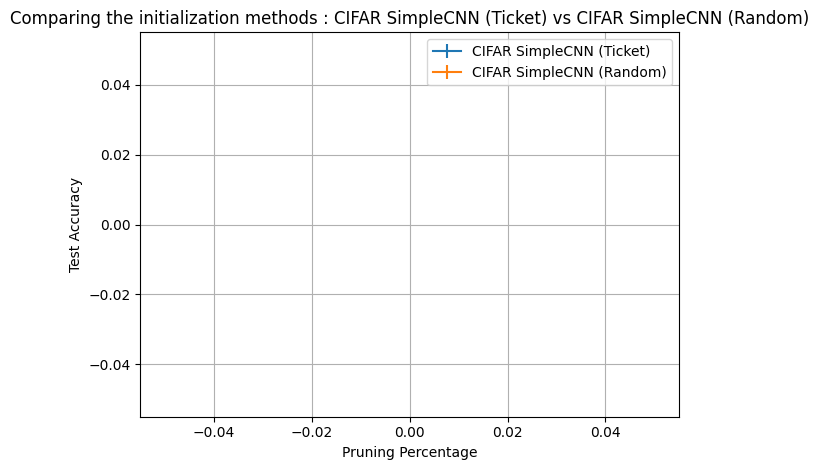

In [7]:
# Génération du graphique de test
comparing_methods_plotting(
    df_cifar_lth, 
    df_cifar_rand, 
    "CIFAR SimpleCNN (Ticket)", 
    "CIFAR SimpleCNN (Random)"
)

## 2. Phase 2 : Extension et Analyse Comparative
Nous cherchons à comparer l'efficacité de la méthode "Lottery Ticket" par rapport aux méthodes d'élagage standard (Fine-Tuning), comme discuté dans l'Annexe B du papier[cite: 651].

* **Comparaison Stratégie 1 vs Stratégie 2 :**
   -  **Stratégie 1 (Winning Ticket) :** Après élagage, on **réinitialise** les poids à $\theta_0$ avant de ré-entraîner .
   -  **Stratégie 2 (Standard Fine-Tuning) :** Après élagage, on **conserve** les poids entraînés $\theta_j$ et on continue l'entraînement.
* **Objectif :** Vérifier si le "Resetting" permet effectivement d'atteindre une meilleure précision ou convergence sur des réseaux très clairsemés.


STARTING PHASE 2: STRATEGY 1 (RESET) VS STRATEGY 2 (FINE-TUNE) ON MNIST


  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 92.82%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.35% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 34.82%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 34.82%
Accuracy after retraining: 94.33%

--- Round 2/7 ---
Current pruning percentage (Method 1): 57.51%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 57.51%
Accuracy after retraining: 93.34%

--- Round 3/7 ---
Current pruning percentage (Method 1): 72.30%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 72.30%
Accuracy after retraining: 94.53%

--- Round 4/7 ---
Current pruning percentage (Method 1): 81.95%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 81.95%
Ac

 20%|██        | 1/5 [05:24<21:36, 324.24s/it]

Accuracy after retraining: 95.77%

Iteration for average : 2/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.59%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.35% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 34.82%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 34.82%
Accuracy after retraining: 92.46%

--- Round 2/7 ---
Current pruning percentage (Method 1): 57.51%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 57.51%
Accuracy after retraining: 93.85%

--- Round 3/7 ---
Current pruning percentage (Method 1): 72.30%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 72.30%
Accuracy after retraining: 93.43%

--- Round 4/7 ---
Current pruning percentage (Method 1): 81.95%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Cur

...

Accuracy after retraining: 96.48%

Iteration for average : 4/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.5%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.35% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 34.82%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 34.82%
Accuracy after retraining: 92.25%

--- Round 2/7 ---
Current pruning percentage (Method 1): 57.51%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 57.51%
Accuracy after retraining: 91.86%

--- Round 3/7 ---
Current pruning percentage (Method 1): 72.30%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 72.30%
Accuracy after retraining: 91.80%

--- Round 4/7 ---
Current pruning percentage (Method 1): 81.95%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Curr

 80%|████████  | 4/5 [21:36<05:24, 324.33s/it]

Accuracy after retraining: 96.53%

Iteration for average : 5/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.12%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.35% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 34.82%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 34.82%
Accuracy after retraining: 91.32%

--- Round 2/7 ---
Current pruning percentage (Method 1): 57.51%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 57.51%
Accuracy after retraining: 87.52%

--- Round 3/7 ---
Current pruning percentage (Method 1): 72.30%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 72.30%
Accuracy after retraining: 90.25%

--- Round 4/7 ---
Current pruning percentage (Method 1): 81.95%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Cur

100%|██████████| 5/5 [27:02<00:00, 324.41s/it]

Accuracy after retraining: 95.56%
27.03418188492457


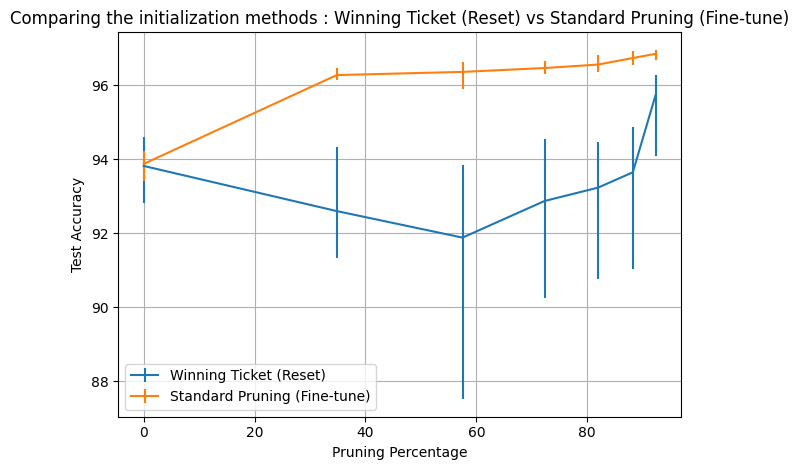

In [4]:
########################### PHASE 2: COMPARISON STRATEGY 1 vs 2 (MNIST) ###########################

print("\n" + "="*50)
print("STARTING PHASE 2: STRATEGY 1 (RESET) VS STRATEGY 2 (FINE-TUNE) ON MNIST")
print("="*50)

# Paramètres pour une expérience significative sur CPU (MNIST est rapide)
# On veut voir la divergence quand le réseau devient très vide (sparsity élevée)
mnist_repeats = 5       # 3 répétitions pour avoir une moyenne fiable
mnist_rounds = 7       # 15 rounds pour élaguer agressivement (~3-4% de poids restants)
mnist_epochs = 5        # Assez pour converger sur MNIST

def method_mnist_strategy_1():
    # Strategy 1 = Reset to Theta_0 (Winning Ticket)
    return iterative_pruning_MNIST(
        total_prune_percent=95,
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,        
        LTH=True,
        strategy_1=True
    )

def method_mnist_strategy_2():
    # Strategy 2 = Keep Theta_j (Standard Fine-Tuning)
    return iterative_pruning_MNIST(
        total_prune_percent=95,
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,
        LTH=True,
        strategy_1=False 
    )

# Lancement de la comparaison
df_strat1, df_strat2 = comparing_methods_initialization_after_pruning(
    amount_of_repeats=mnist_repeats,
    rounds=mnist_rounds,
    method_1=method_mnist_strategy_1,
    method_2=method_mnist_strategy_2
)

# Plotting
comparing_methods_plotting(
    df_strat1,
    df_strat2,
    "Winning Ticket (Reset)",
    "Standard Pruning (Fine-tune)"
)

### Comparaison de la méthode one-shot à la méthode de pruning itérative


  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 92.76%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.18% of the weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 18.10%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 18.10%
Accuracy after retraining: 95.19%

--- Round 2/15 ---
Current pruning percentage (Method 1): 32.93%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 32.93%
Accuracy after retraining: 95.17%

--- Round 3/15 ---
Current pruning percentage (Method 1): 45.07%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 45.07%
Accuracy after retraining: 94.66%

--- Round 4/15 ---
Current pruning percentage (Method 1): 55.02%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 55.05

 20%|██        | 1/5 [09:20<37:23, 560.82s/it]

Accuracy after retraining: 96.63%

Iteration for average : 2/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 94.19%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.18% of the weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 18.10%
Pruning threshold: 0.04
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 18.10%
Accuracy after retraining: 95.04%

--- Round 2/15 ---
Current pruning percentage (Method 1): 32.93%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 32.93%
Accuracy after retraining: 95.47%

--- Round 3/15 ---
Current pruning percentage (Method 1): 45.07%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 45.07%
Accuracy after retraining: 94.03%

--- Round 4/15 ---
Current pruning percentage (Method 1): 55.02%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros

 40%|████      | 2/5 [18:56<28:28, 569.38s/it]

...

Accuracy after retraining: 95.93%

Iteration for average : 4/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.62%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.18% of the weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 18.10%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 18.10%
Accuracy after retraining: 94.85%

--- Round 2/15 ---
Current pruning percentage (Method 1): 32.93%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 32.93%
Accuracy after retraining: 95.30%

--- Round 3/15 ---
Current pruning percentage (Method 1): 45.07%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 45.07%
Accuracy after retraining: 94.50%

--- Round 4/15 ---
Current pruning percentage (Method 1): 55.02%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros

 80%|████████  | 4/5 [38:02<09:31, 571.66s/it]

Accuracy after retraining: 97.29%

Iteration for average : 5/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 93.88%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.18% of the weights.

--- Round 1/15 ---
Current pruning percentage (Method 1): 18.10%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 18.10%
Accuracy after retraining: 94.62%

--- Round 2/15 ---
Current pruning percentage (Method 1): 32.93%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 32.93%
Accuracy after retraining: 93.12%

--- Round 3/15 ---
Current pruning percentage (Method 1): 45.07%
Pruning threshold: 0.01
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 45.07%
Accuracy after retraining: 94.24%

--- Round 4/15 ---
Current pruning percentage (Method 1): 55.02%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros

100%|██████████| 5/5 [47:40<00:00, 572.15s/it]

Accuracy after retraining: 97.36%
47.67959036429723


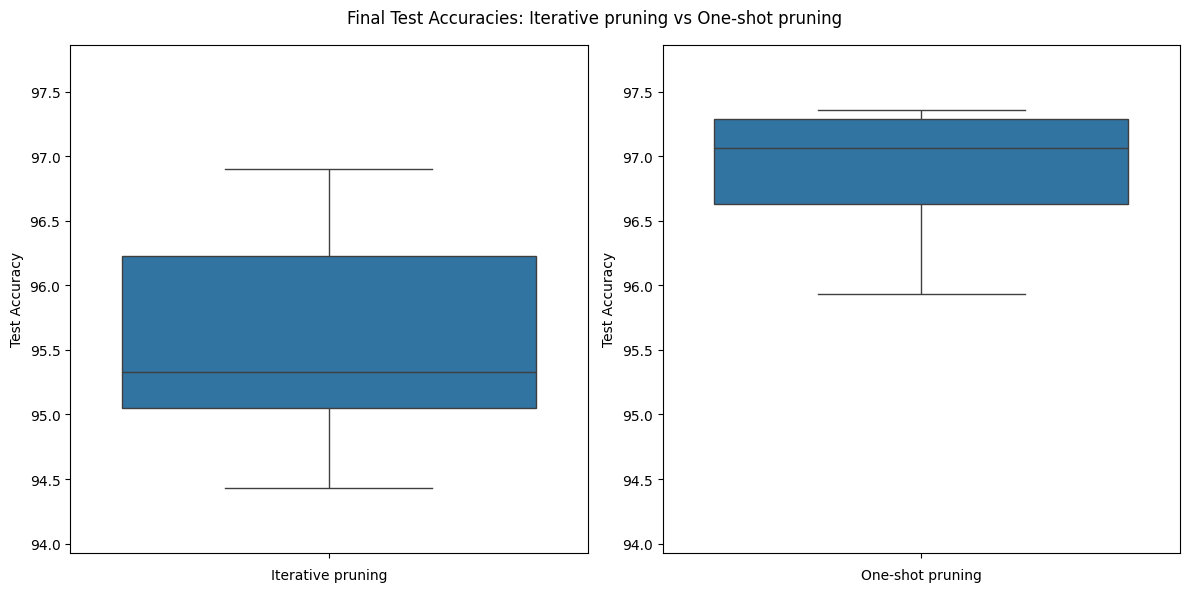

In [3]:
repeats = 5    
mnist_rounds = 15    
mnist_epochs = 10    

def method_mnist_iterative():
    # Method 1 : iterative pruning
    return iterative_pruning_MNIST(
        total_prune_percent=95,
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,        
        LTH=True,
        one_shot = False
    )

def method_mnist_one_shot():
    # Method 2 = One shot pruning
    return iterative_pruning_MNIST(
        total_prune_percent=95,
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,
        LTH=True,
        one_shot = True
    )

# Lancement de la comparaison
df_strat1, df_strat2 = comparing_pruning_methods(
    amount_of_repeats=repeats,
    rounds=mnist_rounds,
    method_1=method_mnist_iterative,
    method_2=method_mnist_one_shot
)

# Plotting
comparing_pruning_methods_plotting(
    df_strat1,
    df_strat2,
    mnist_rounds,
    "Iterative pruning",
    "One-shot pruning"
)
